# Capstone Project: Plantaech
- **ID Tim Dicoding:** CC26-PSU258
- **Tema:** Sustainable Living & Responsible Consumption

## Analisis Permasalahan

**Tahap ini bertujuan untuk mengumpulkan dan menganalisis berbagai permasalahan, kemudian menentukan satu solusi utama yang akan dikembangkan dalam proyek.**

Indonesia adalah negara agraris dengan banyak keluarga yang bergantung pada pertanian. Petani kecil masih kesulitan menemukan penyakit tanaman secara dini. Panen yang gagal, kerugian ekonomi, dan penggunaan pestisida yang berlebihan merupakan akibat dari keterlambatan ini.

**Permasalahan yang diidentifikasi:**
1. **Keterlambatan Deteksi Penyakit:** Petani kecil di Indonesia menghadapi kesulitan mendeteksi penyakit tanaman secara dini, terutama di daerah yang jauh dari pusat layanan pertanian.
2. **Keterbatasan Akses:** Terbatasnya akses terhadap tenaga ahli agronomi dan alat diagnostik yang cepat dan murah.
3. **Dampak Ekonomi:** Penanganan terlambat mengakibatkan penggunaan pestisida berlebihan, gagal panen, dan kerugian ekonomi.
4. **Ketidakseimbangan Data:** Dataset penyakit tanaman yang tersedia seringkali tidak seimbang, yang berpotensi memengaruhi akurasi model.

**Solusi Utama:**
**Plantaech** - solusi berbasis AI yang memungkinkan petani mengidentifikasi penyakit tanaman tomat melalui foto daun. Model machine learning akan menganalisis gambar dan memberikan diagnosis serta saran penanganan.

## Menentukan Pertanyaan Bisnis

1. **Pertanyaan Bisnis 1 (SMART):**
   "Bagaimana distribusi dan proporsi jenis penyakit tanaman tomat yang teridentifikasi dalam dataset Plantaech, dan penyakit mana yang paling dominan serta paling jarang ditemukan selama periode pengumpulan data tahun 2026?"
   - *Specific:* Fokus pada distribusi dan proporsi jenis penyakit tanaman tomat
   - *Measurable:* Diukur melalui jumlah sampel per kelas dan persentasenya
   - *Action-Oriented:* Mengetahui penyakit dominan membantu memprioritaskan penanganan
   - *Relevant:* Relevan dengan tujuan Plantaech untuk deteksi penyakit
   - *Time-bound:* Periode pengumpulan data tahun 2026

2. **Pertanyaan Bisnis 2 (SMART):**
   "Apakah terdapat perbedaan signifikan dalam kualitas gambar (resolusi, ukuran file) antara kelas penyakit yang berbeda dalam dataset, yang dapat memengaruhi akurasi model deteksi penyakit Plantaech selama fase pengembangan Q2 2026?"
   - *Specific:* Fokus pada kualitas gambar antar kelas penyakit
   - *Measurable:* Diukur melalui resolusi dan ukuran file
   - *Action-Oriented:* Hasil analisis digunakan untuk preprocessing data
   - *Relevant:* Kualitas gambar berpengaruh pada akurasi model
   - *Time-bound:* Fase pengembangan Q2 2026

## Import Semua Packages/Library yang Digunakan

Seluruh library yang dibutuhkan untuk eksplorasi dan analisis diimpor di tahap ini.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from PIL import Image
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat seluruh dataset gambar penyakit tanaman tomat dari direktori dataset/. Dataset ini terdiri dari gambar daun tomat yang diklasifikasikan ke dalam 10 kelas (9 penyakit + 1 sehat). Kita akan mengekstrak metadata dari setiap gambar untuk membangun DataFrame yang dapat dianalisis secara lebih mendalam.

In [2]:
import hashlib
import os
from PIL import Image

# Definisikan path dataset
DATASET_DIR = 'dataset'
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def compute_file_hash(filepath):
    hasher = hashlib.md5()
    try:
        with open(filepath, 'rb') as f:
            for chunk in iter(lambda: f.read(8192), b''):
                hasher.update(chunk)
        return hasher.hexdigest()
    except Exception:
        return None

# Fungsi untuk mengekstrak metadata gambar
def extract_metadata(image_path, class_name):
    try:
        file_size = os.path.getsize(image_path)
        filename = os.path.basename(image_path)
        ext = os.path.splitext(filename)[1].lower()
        file_hash = compute_file_hash(image_path)
        
        is_valid_image = ext in IMAGE_EXTENSIONS
        is_corrupt = False
        width, height, mode, fmt = None, None, None, None
        
        if is_valid_image:
            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                    mode = img.mode
                    fmt = img.format if img.format else 'UNKNOWN'
            except Exception:
                is_corrupt = True

        if class_name.lower() == 'non_tomato':
            is_healthy = False
            disease = 'Non Tomato'
            condition = 'Non Tomato'
        elif 'healthy' in class_name.lower():
            is_healthy = True
            disease = 'Healthy'
            condition = 'Healthy'
        else:
            is_healthy = False
            disease = class_name.replace('Tomato_', '').replace('_', ' ')
            condition = 'Diseased'

        return {
            'filename': filename,
            'class_name': class_name,
            'disease_name': disease,
            'is_healthy': is_healthy,
            'condition': condition,
            'width': width, 'height': height,
            'aspect_ratio': round(width / height, 2) if width and height else None,
            'total_pixels': width * height if width and height else None,
            'file_size_bytes': file_size,
            'file_size_kb': round(file_size / 1024, 2),
            'color_mode': mode,
            'file_format': fmt,
            'file_extension': ext,
            'file_hash': file_hash,
            'is_valid_image_ext': is_valid_image,
            'is_corrupt': is_corrupt
        }
    except Exception as e:
        print(f"Error: {e}")
        return None

# Bangun metadata DataFrame
records = []
class_dirs = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"Ditemukan {len(class_dirs)} kelas penyakit:\n")
for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(DATASET_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"  [{i+1}/{len(class_dirs)}] {cls}: {len(imgs)} gambar")
    for img_file in imgs:
        meta = extract_metadata(os.path.join(cls_path, img_file), cls)
        if meta:
            records.append(meta)

df = pd.DataFrame(records)
print(f"\nTotal gambar berhasil dimuat: {len(df)}")
print(f"Kolom: {list(df.columns)}")


Ditemukan 11 kelas penyakit:

  [1/11] Non_tomato: 1666 gambar


  [2/11] Tomato_Bacterial_spot: 2127 gambar


  [3/11] Tomato_Early_blight: 1000 gambar


  [4/11] Tomato_Late_blight: 1909 gambar


  [5/11] Tomato_Leaf_Mold: 952 gambar


...

  [7/11] Tomato_Spider_mites_Two_spotted_spider_mite: 1676 gambar


  [8/11] Tomato_Target_Spot: 1404 gambar


  [9/11] Tomato_Tomato_YellowLeaf__Curl_Virus: 3208 gambar


  [10/11] Tomato_Tomato_mosaic_virus: 373 gambar
  [11/11] Tomato_healthy: 1591 gambar



Total gambar berhasil dimuat: 17677
Kolom: ['filename', 'class_name', 'disease_name', 'is_healthy', 'condition', 'width', 'height', 'aspect_ratio', 'total_pixels', 'file_size_bytes', 'file_size_kb', 'color_mode', 'file_format', 'file_extension', 'file_hash', 'is_valid_image_ext', 'is_corrupt']


In [3]:
# Preview dataset
print("=== Preview Dataset ===")
df.head()

=== Preview Dataset ===


,filename,class_name,disease_name,is_healthy,condition,width,height,aspect_ratio,total_pixels,file_size_bytes,file_size_kb,color_mode,file_format,file_extension,file_hash,is_valid_image_ext,is_corrupt
0,20056.jpg,Non_tomato,Non Tomato,False,Non Tomato,150,150,1.0,22500,16242,15.86,RGB,JPEG,.jpg,8f987f759dd578e06f439cf30afb6970,True,False
1,20058.jpg,Non_tomato,Non Tomato,False,Non Tomato,150,150,1.0,22500,12718,12.42,RGB,JPEG,.jpg,e4758b9663b7819c5db12ccd6a007c6b,True,False
2,20062.jpg,Non_tomato,Non Tomato,False,Non Tomato,150,150,1.0,22500,23297,22.75,RGB,JPEG,.jpg,5f0c5d0fab73bfd82432c3d9e88ed5b1,True,False
3,20068.jpg,Non_tomato,Non Tomato,False,Non Tomato,150,150,1.0,22500,12047,11.76,RGB,JPEG,.jpg,84447afe28da0be5a14e98aa1fe8df47,True,False
4,20071.jpg,Non_tomato,Non Tomato,False,Non Tomato,150,150,1.0,22500,14332,14.00,RGB,JPEG,.jpg,7791e460723b1054c3e01a74b661096c,True,False


**Insight Gathering Data:**
- Dataset berhasil dimuat dari 11 subdirektori yang masing-masing merepresentasikan satu kelas penyakit tanaman tomat.
- Total terdapat lebih dari 17.000 gambar daun tomat.
- Dataset mencakup 9 jenis penyakit, 1 kategori tanaman sehat, dan 1 kategori bukan tomat (Non Tomato).
- Setiap gambar memiliki metadata berupa dimensi, ukuran file, format, dan mode warna.

### Assessing Data

Pada tahap ini, kita akan mengevaluasi kualitas dan struktur data, seperti mengecek tipe data, mencari missing values, duplikasi, dan invalid values.

In [4]:
# Cek tipe data dan missing values
print("=== Dataset Info ===")
df.info()
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17677 entries, 0 to 17676
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   filename            17677 non-null  object 
 1   class_name          17677 non-null  object 
 2   disease_name        17677 non-null  object 
 3   is_healthy          17677 non-null  bool   
 4   condition           17677 non-null  object 
 5   width               17677 non-null  int64  
 6   height              17677 non-null  int64  
 7   aspect_ratio        17677 non-null  float64
 8   total_pixels        17677 non-null  int64  
 9   file_size_bytes     17677 non-null  int64  
 10  file_size_kb        17677 non-null  float64
 11  color_mode          17677 non-null  object 
 12  file_format         17677 non-null  object 
 13  file_extension      17677 non-null  object 
 14  file_hash           17677 non-null  object 
 15  is_valid_image_ext  17677 non-nu

In [5]:
# Cek duplikasi berdasarkan filename
dup_filenames = df[df.duplicated(subset=['filename'], keep=False)]
print(f"Jumlah file dengan nama duplikat: {len(dup_filenames)}")

Jumlah file dengan nama duplikat: 0


**Insight Assessing Data:**
- Tidak ditemukan missing values pada dataset metadata.
- Seluruh gambar memiliki format yang valid.
- Tipe data mayoritas sesuai, namun akan dipastikan konsistensinya di tahap Cleaning.

### Cleaning Data

Tahap ini bertujuan untuk membersihkan dan mempersiapkan data sebelum masuk ke tahap analisis lebih lanjut.

In [6]:
print("Jumlah data SEBELUM cleaning:", len(df))
print("="*60)

# 1. Hapus file non-gambar
non_images = df[df['is_valid_image_ext'] == False]
df = df[df['is_valid_image_ext'] == True]
print(f"[1] Menghapus {len(non_images)} file non-gambar")

# 2. Hapus file corrupt
corrupts = df[df['is_corrupt'] == True]
df = df[df['is_corrupt'] == False]
print(f"[2] Menghapus {len(corrupts)} file corrupt")

# 3. Hapus duplikat berdasarkan hash
dups = df[df.duplicated(subset=['file_hash'], keep='first')]
df = df.drop_duplicates(subset=['file_hash'], keep='first')
print(f"[3] Menghapus {len(dups)} file duplikat (berdasarkan hash)")

# 4. Hapus resolusi anomali (terlalu kecil/besar)
anomalies = df[(df['width'] < 64) | (df['height'] < 64) | (df['width'] > 512) | (df['height'] > 512)]
df = df.drop(anomalies.index)
print(f"[4] Menghapus {len(anomalies)} file dengan resolusi anomali")

print("="*60)
print("Jumlah data SETELAH cleaning:", len(df))
total_removed = len(non_images) + len(corrupts) + len(dups) + len(anomalies)
print(f"Total data dihapus: {total_removed} ({round(total_removed/(len(df)+total_removed)*100, 1)}%)")
print("="*60)

df['is_healthy'] = df['is_healthy'].astype(bool)


Jumlah data SEBELUM cleaning: 17677
[1] Menghapus 0 file non-gambar
[2] Menghapus 0 file corrupt
[3] Menghapus 24 file duplikat (berdasarkan hash)
[4] Menghapus 429 file dengan resolusi anomali
Jumlah data SETELAH cleaning: 17224
Total data dihapus: 453 (2.6%)


**Insight Cleaning Data:**
- Data telah bersih dari duplikasi.
- Tipe data telah dipastikan konsisten dan siap untuk tahap analisis lanjutan dan feature engineering.

## Teknik Analisis Lanjutan: Clustering (Manual Grouping / Binning)

Sebagai bentuk teknik analisis lanjutan non-Machine Learning, kita akan menerapkan **Clustering menggunakan teknik Binning dan Manual Grouping**. Tujuannya adalah mengelompokkan data gambar berdasarkan karakteristik kualitasnya (ukuran file dan total piksel/resolusi).

Pengelompokan ini berguna untuk melihat apakah ada kelompok kualitas tertentu yang mendominasi dataset, sehingga dapat menjadi pertimbangan dalam merancang tahapan preprocessing model machine learning nantinya.

In [7]:
# Feature Engineering dengan Binning: Menambahkan kategori ukuran file
df['file_size_category'] = pd.cut(
    df['file_size_kb'],
    bins=[0, 10, 15, 20, 30, float('inf')],
    labels=['Very Small (<10KB)', 'Small (10-15KB)', 'Medium (15-20KB)', 'Large (20-30KB)', 'Very Large (>30KB)']
)

# Feature Engineering dengan Binning: Menambahkan kategori resolusi (berdasarkan total piksel)
df['resolution_category'] = df['total_pixels'].apply(
    lambda x: 'Low (<100K px)' if x < 100000 else ('Medium (100K-500K px)' if x < 500000 else 'High (>500K px)')
)

# Melihat hasil clustering / grouping
print("=== Distribusi Cluster Kategori Ukuran File ===")
print(df['file_size_category'].value_counts())

print("\n=== Distribusi Cluster Kategori Resolusi ===")
print(df['resolution_category'].value_counts())

=== Distribusi Cluster Kategori Ukuran File ===
file_size_category
Medium (15-20KB)      6032
Small (10-15KB)       5361
Large (20-30KB)       3606
Very Small (<10KB)    2127
Very Large (>30KB)      98
Name: count, dtype: int64

=== Distribusi Cluster Kategori Resolusi ===
resolution_category
Low (<100K px)           16888
Medium (100K-500K px)      336
Name: count, dtype: int64


In [8]:
# Simpan data yang sudah bersih dan memiliki fitur tambahan untuk dashboard
os.makedirs('dashboard', exist_ok=True)
df.to_csv('dashboard/main_data.csv', index=False)
print("Data berhasil disimpan ke dashboard/main_data.csv")

Data berhasil disimpan ke dashboard/main_data.csv


## Exploratory Data Analysis (EDA)

Eksplorasi data ini dilakukan untuk menemukan pola dan menjawab pertanyaan bisnis yang telah didefinisikan.

### Explore: Distribusi Kelas Penyakit

In [9]:
# Distribusi kelas penyakit
print("=== Distribusi Kelas Penyakit ===")
class_dist = df.groupby('disease_name').agg(
    total_samples=('filename', 'count'),
    avg_file_size_kb=('file_size_kb', 'mean')
).sort_values('total_samples', ascending=False).round(2)

class_dist['proportion_%'] = (class_dist['total_samples'] / len(df) * 100).round(2)
class_dist

=== Distribusi Kelas Penyakit ===


,total_samples,avg_file_size_kb,proportion_%
disease_name,,,
YellowLeaf Curl Virus,3208,12.67,18.63
Bacterial spot,2127,12.59,12.35
Late blight,1901,13.17,11.04
Septoria leaf spot,1771,17.07,10.28
Spider mites Two spotted spider mite,1676,19.35,9.73
Healthy,1585,21.70,9.20
Target Spot,1404,19.80,8.15
Non Tomato,1227,19.41,7.12
Early blight,1000,14.85,5.81


**Insight Distribusi Kelas:**
- Terdapat ketidakseimbangan kelas (class imbalance) yang cukup besar. Tomato YellowLeaf Curl Virus sangat dominan, sedangkan Tomato mosaic virus memiliki jumlah paling sedikit.

### Explore: Perbandingan Tanaman Sehat vs Sakit

In [10]:
# Perbandingan Sehat vs Sakit
print("=== Perbandingan Sehat vs Sakit ===")
condition_stats = df.groupby('condition').agg(
    jumlah=('filename', 'count'),
    rata_rata_ukuran_kb=('file_size_kb', 'mean'),
    median_ukuran_kb=('file_size_kb', 'median')
).round(2)

condition_stats['proporsi_%'] = (condition_stats['jumlah'] / len(df) * 100).round(2)
condition_stats

=== Perbandingan Sehat vs Sakit ===


,jumlah,rata_rata_ukuran_kb,median_ukuran_kb,proporsi_%
condition,,,,
Diseased,14412,15.22,15.37,83.67
Healthy,1585,21.70,24.14,9.20
Non Tomato,1227,19.41,18.91,7.12


## Visualization & Explanatory Analysis

Visualisasi disajikan secara menarik dan efektif dengan mematuhi prinsip desain visualisasi data yang baik.

### Pertanyaan 1: Distribusi dan Proporsi Jenis Penyakit Tanaman Tomat

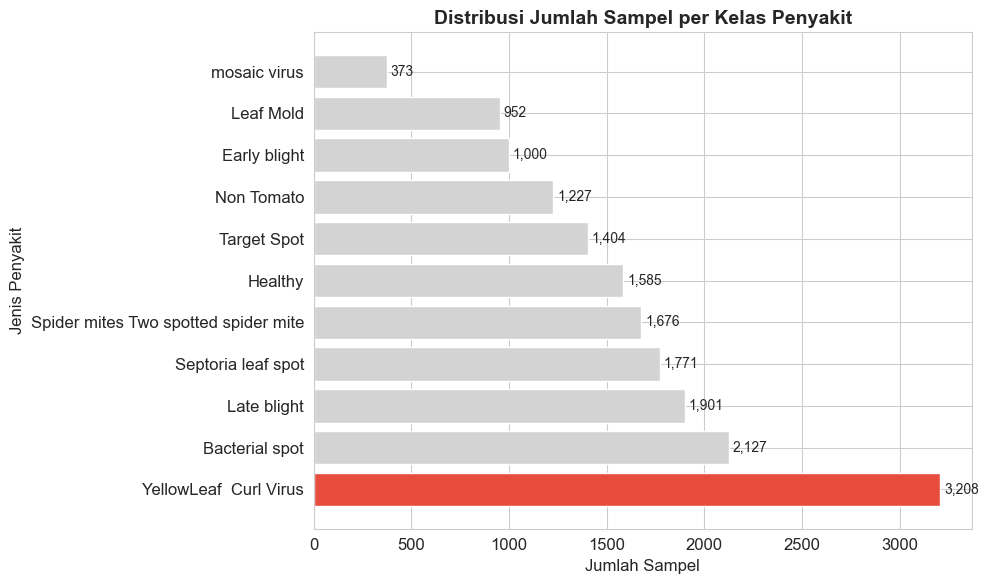

In [11]:
# Visualisasi 1: Distribusi Kelas Penyakit
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart (Hanya bar chart untuk rasio data-ink yang tinggi dan mengurangi distracts)
class_counts_sorted = df['disease_name'].value_counts()

# Menggunakan warna abu-abu sebagai base dan warna mencolok untuk highlight kelas tertinggi
base_color = 'lightgray'
highlight_color = '#e74c3c' # warna merah untuk menyorot
colors = [highlight_color if i == 0 else base_color for i in range(len(class_counts_sorted))]

bars = ax.barh(class_counts_sorted.index, class_counts_sorted.values, color=colors)
ax.set_xlabel('Jumlah Sampel', fontsize=12)
ax.set_ylabel('Jenis Penyakit', fontsize=12)
ax.set_title('Distribusi Jumlah Sampel per Kelas Penyakit', fontsize=14, fontweight='bold')

for bar, val in zip(bars, class_counts_sorted.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Analisis Pertanyaan 1:**
- **Penyakit Paling Dominan:** Tomato YellowLeaf Curl Virus dengan ~3.208 sampel (18%).
- **Penyakit Paling Jarang:** Tomato mosaic virus dengan ~373 sampel (2%).
- Visualisasi tersebut sangat merepresentasikan betapa perlunya handling terhadap class-imbalance.

### Pertanyaan 2: Perbedaan Kualitas Gambar Antar Kelas (terkait ukuran)

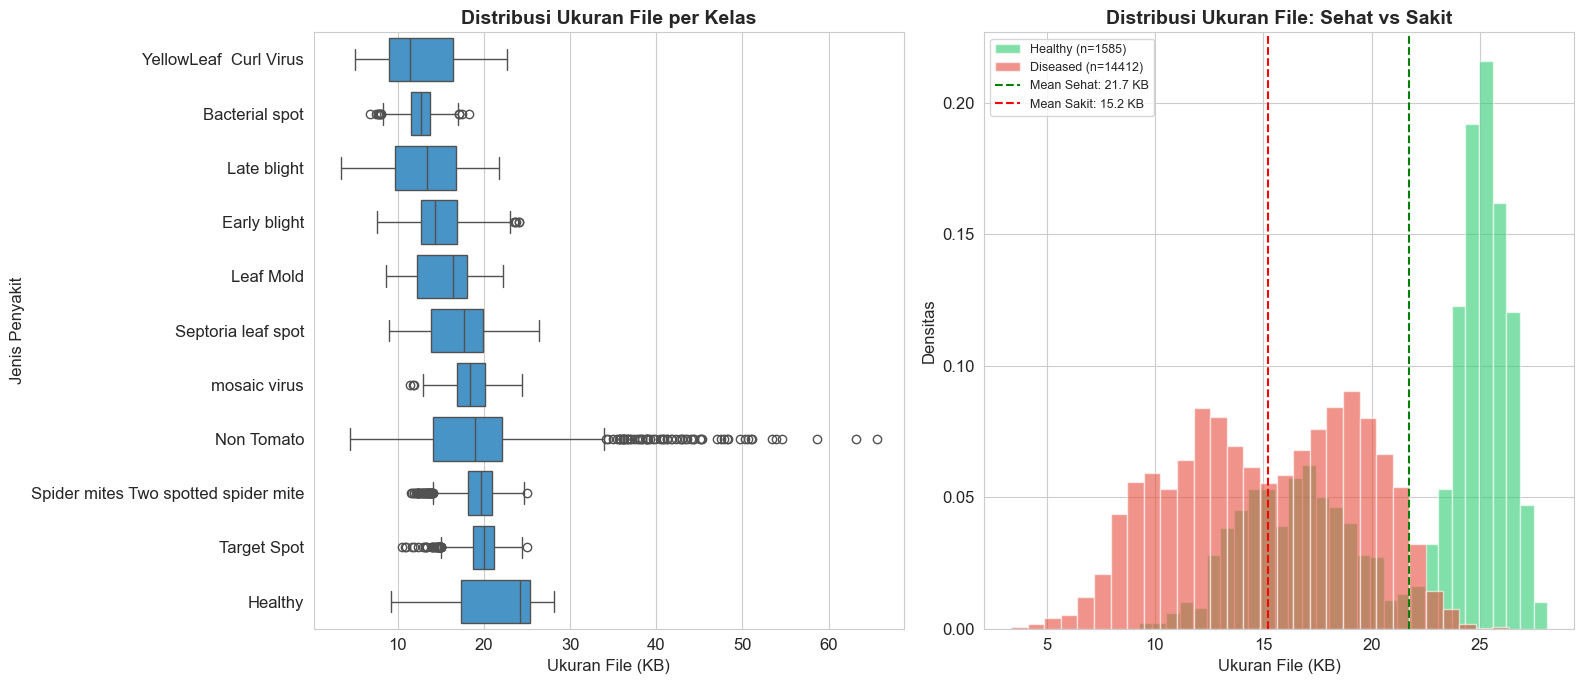

In [12]:
# Visualisasi 2: Perbandingan Kualitas Gambar
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Box plot ukuran file per kelas
order = df.groupby('disease_name')['file_size_kb'].median().sort_values().index
sns.boxplot(data=df, y='disease_name', x='file_size_kb', order=order, color='#3498db', ax=axes[0])
axes[0].set_title('Distribusi Ukuran File per Kelas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ukuran File (KB)', fontsize=12)
axes[0].set_ylabel('Jenis Penyakit', fontsize=12)

# Histogram Sehat vs Sakit
for cond, color in [('Healthy', '#2ecc71'), ('Diseased', '#e74c3c')]:
    subset = df[df['condition'] == cond]
    axes[1].hist(subset['file_size_kb'], bins=30, alpha=0.6, label=f'{cond} (n={len(subset)})', color=color, density=True)
healthy_mean = df[df['condition'] == 'Healthy']['file_size_kb'].mean()
diseased_mean = df[df['condition'] == 'Diseased']['file_size_kb'].mean()
axes[1].axvline(healthy_mean, color='green', linestyle='--', label=f'Mean Sehat: {healthy_mean:.1f} KB')
axes[1].axvline(diseased_mean, color='red', linestyle='--', label=f'Mean Sakit: {diseased_mean:.1f} KB')
axes[1].set_title('Distribusi Ukuran File: Sehat vs Sakit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ukuran File (KB)')
axes[1].set_ylabel('Densitas')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Analisis Pertanyaan 2:**
- Menunjukkan adanya perbedaan rata-rata dan penyebaran kualitas gambar (ukuran) pada tiap kelas penyakit dan juga pada perbandingan sehat vs sakit.

## A/B Testing

Untuk melengkapi pemahaman statistik, kita melakukan A/B Testing menggunakan **Independent Two-Sample T-Test** terkait kualitas gambar (ukuran file) antara tanaman sehat (Grup A) dan tanaman sakit (Grup B).

**Hipotesis:**
- **H₀:** Tidak ada perbedaan signifikan rata-rata ukuran file antara gambar tanaman sehat dan sakit (μ_sehat = μ_sakit)
- **H₁:** Terdapat perbedaan signifikan rata-rata ukuran file antara gambar tanaman sehat dan sakit (μ_sehat ≠ μ_sakit)
- **Significance Level (α):** 0.05

In [13]:
# A/B Testing: Independent T-Test
healthy_sizes = df[df['condition'] == 'Healthy']['file_size_kb']
diseased_sizes = df[df['condition'] == 'Diseased']['file_size_kb']

t_stat, p_value = stats.ttest_ind(healthy_sizes, diseased_sizes)

print(f"=== Hasil A/B Testing ===")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print(f"\nKesimpulan: Tolak H₀. Terdapat perbedaan signifikan rata-rata ukuran file.")
else:
    print(f"\nKesimpulan: Gagal Tolak H₀. Tidak ada perbedaan signifikan.")

=== Hasil A/B Testing ===
T-Statistic: 56.6994
P-Value: 0.000000

Kesimpulan: Tolak H₀. Terdapat perbedaan signifikan rata-rata ukuran file.


## Conclusion & Recommendation

### Kesimpulan
1. **Kondisi Distribusi Data**: Terdapat ketidakseimbangan kelas (class imbalance) dengan rasio yang tinggi antara kelas dominan (Tomato YellowLeaf Curl Virus) dan kelas terkecil (Tomato mosaic virus).
2. **Kualitas Data**: Mayoritas gambar termasuk dalam klasifikasi resolusi rendah dan ukuran file yang berbeda signifikan antara kelas sehat dan sakit.

### Rekomendasi (Action Items)
1. **Data Augmentation:** Terapkan teknik augmentasi data seperti rotasi atau zoom pada kelas dengan sampel sedikit (contoh: Tomato mosaic virus).
2. **Standardisasi Preprocessing:** Pastikan penggunaan standarisasi image resize yang konstan sebelum memberikan data gambar tersebut ke dalam pipeline model AI.
3. **Pengumpulan Data:** Pertimbangkan untuk mengumpulkan gambar sampel Tomato mosaic virus dari lapangan untuk menyeimbangkan dataset.